In [51]:
from IPython.display import display,HTML
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import date


class Netflix_title:
    def header(self,header,font=("arial",15,"bold")):
        display(HTML(f"<h2 style = text-align:center;color:green > {header} </h2>"))

    def Numpy(self,data):
        self.header("Percentage of MOvies & TV shows")
        print(round((data["type"].value_counts()/len(data))*100,2))
        self.header("Average release year")
        print(round(data["release_year"].mean(),2))
        self.header("Determine the oldest and newest content")
        print("oldest  : ",data['release_year'].min())
        print("Newest : ",data['release_year'].max())
        self.header("Percentage of missing values in the director")
        print(round((data['director'].isna().sum()/len(data))*100,2))
        self.header("Top 20 most recent release years and count titles")
        print(data["release_year"].value_counts().head(20).sort_index(ascending=False))
        self.header("standard deviation of release year")
        print(round(data['release_year'].std()),2)
        self.header("identify all content released before year 2000")
        display(data[data['release_year']<2000])
        self.header("percentage of content added ot netflix after 2018")
        print(round(((data['release_year']>2018).sum()/len(data))*100,2))
        self.header("difference between earliest and latest released year")
        print(data['release_year'].max() - data['release_year'].min())
        self.header("numpy array containing release years between 2015 and 2020")


    def content(self,data):
        self.header("Highest number of netflix titles")
        new = data['country'].value_counts()
        print(new[new == new.max()])
        self.header("Director has directed the highest number of titles")
        print(data['director'].value_counts().head(1))
        self.header("Actor appears in the largest number of netflix titles")
        print(data['cast'].dropna().str.split(",").explode().value_counts().head(1))
        self.header("Highest number of releases")
        print(data['release_year'].value_counts().head(1))
        self.header("Month sees the highest number of titles added ot netflix")
        data["date_added"] = pd.to_datetime(data["date_added"],
                                            errors="coerce")
        print(data["date_added"].dt.month_name().value_counts().head(1))
        self.header("Number of movies and TV shows released each year")
        print(data.groupby(["release_year", "type"]).size().unstack(fill_value=0))
        self.header("Rating appears most frequently")
        print(data['rating'].value_counts().head(1))
        self.header("Genre has the highest number of title")
        print(data["listed_in"].str.split(", ").explode().value_counts().head(1))
        self.header("Five countries with the fastest-growing netflix-libraries over time")
        self.header("Decade(1980s,1990s,2000s,2010s,2020s) contributed the most content")
        print(((data["release_year"] // 10) * 10).value_counts().head(1))


    def Data_wrangling(self,data):
        self.header("listed_in column and find the top 15 genres")
        print(data['listed_in'].str.split(",").explode().value_counts().head(15))
        self.header("cast column and identify the top 20 most frequent actors")
        print(data['cast'].str.split(",").explode().value_counts().head(20))
        self.header("top 15 contributing countries")
        print(data['country'].str.split(",").value_counts().head(15))
        self.header("create column named content_age(current year - relesed date)")
        print(date.today().year - data['release_year'])
        self.header("categorize content")
        def category(year):
            if year < 2000:
                return "Classic"
            elif year <=2015:
                return "modern"
            else:
                return "Recent"
            
        data['Categorize'] = data['release_year'].apply(category)
        print(data.head())
        self.header("Directors have directed both movies and tv shows")
        result = (data.groupby("director")["type"].nunique())
        print(result[result == 2])
        self.header("Actors have worked in more the one country")
        res = data.groupby("cast")['country'].nunique()
        print(res[res > 1])
        self.header("find the longest & shortest movie duration")
    

    def Matplotlib(self,data):
        self.header("Netflix content growth over the year")
        new = data['release_year'].value_counts().sort_index()
        plt.figure(figsize=(5,4))
        plt.plot(new.index,new.values,marker='*')
        plt.title("Netflix content growth over the years")
        plt.xlabel("year")
        plt.ylabel("numer of title")
        plt.show()
        self.header("campare movies vs tvshows")
        data['type'].value_counts().plot(kind='bar')
        plt.title("Movies vs TV Shows")
        plt.xlabel("Content Type")
        plt.ylabel("Count")
        plt.show()
        self.header("visualize the top 10 countries y content count")
        country = data['country'].dropna().value_counts().head(10)
        plt.bar(country.index,country.values)
        plt.xticks(rotation=90)
        plt.show()
        self.header("distribution of movie duration")
        movie = data[data['type']=='Movie'].copy()
        movie = movie.dropna(subset=['duration'])
        movie['duration'] = (
            movie['duration']
            .str.replace(' min','',regex=False)
            .astype(int))

        plt.hist(movie['duration'], bins=30)
        plt.title("Movie Duration Distribution")
        plt.xlabel("Duration (Minutes)")
        plt.ylabel("Frequency")
        plt.show()
        self.header("compare content ratings using bar chart")
        new = data['rating'].value_counts()
        plt.bar(new.index,new.values)
        plt.xticks(rotation=90)
        plt.show()
        self.header("create subplot(top genres,top countries)")
        plt.figure(figsize=(14, 5))
        plt.subplot(1, 2, 1)
        genre = (data['listed_in'].str.split(', ').explode().value_counts().head(10))
        plt.bar(genre.index, genre.values)
        plt.title("Top 10 Genres")
        plt.subplot(1, 2, 2)
        country = (data['country'].dropna().str.split(', ').explode().value_counts().head(10))
        plt.bar(country.index, country.values)
        plt.title("Top 10 Countries")
        plt.show()

        self.header("line chart showing yearly content additions")
        new = pd.to_datetime(data['date_added'],errors="coerce").dt.year.value_counts().sort_index()
        plt.plot(new.index,new.values,marker="*")
        plt.title("Showing yearly content additions")
        plt.xlabel("year")
        plt.ylabel("number of title")
        plt.grid(True)
        plt.show()


    def seaborn(self,data):
        self.header("campare release year for movies vs tv shows boxplot")
        plt.figure(figsize=(4,5))
        sns.boxplot(data=data,x='type',y='release_year')
        plt.show()
        self.header("visualize the relationship between content type and rating")
        sns.countplot(data=data,x="rating",hue="type")
        plt.xticks(rotation=40)
        plt.show()
        self.header("heatmap of content relesed by year and type")
        new = pd.crosstab(data['release_year'],data['type'])
        sns.heatmap(new,cmap="coolwarm")
        plt.title("content released by year and type")
        plt.show()
        self.header("distribution of movie durations using a hisogram with kde")
        movie = data[data['type'] == 'Movie']
        movie['duration'] = movie['duration'].str.replace('min',' ').astype(float)
        sns.histplot(movie['duration'],bins=30,kde=True)
        plt.show()
        self.header("violin plot camparing movie durations across ratings")
        movie = data[data['type'] == 'Movie']
        movie['duration'] = movie['duration'].str.replace('min',' ',regex=False).astype(float)
        sns.violinplot(data=movie,x='rating',y='duration')
        plt.xticks(rotation=45)
        plt.show()
        self.header("top 15 genres using a count plot or barplot")
        alfa = data['listed_in'].str.split(",").explode().value_counts().head(15)
        sns.barplot(x=alfa.index,y=alfa.values)
        plt.xticks(rotation=90)
        plt.show()
        self.header("pairplot using available numerical feature")
        sns.pairplot(movie[["release_year","duration",'type']])
        self.header("one custom visualization that reveals an interesting insight about netflix content")
        data['date_added'] = pd.to_datetime(data['date_added'],errors="coerce")
        data['year_added'] = data['date_added'].dt.year
        pd.crosstab(data['year_added'],data['type']).plot(figsize=(10,5),marker='o')
        plt.title("Movies vs TV Shows Added Over Years")
        plt.xlabel("Year")
        plt.ylabel("Count")
        plt.show()

nt = Netflix_title()
data = pd.read_csv("netflix_titles.csv")

# Numpy

In [54]:
nt.Numpy(data)

type
Movie      69.62
TV Show    30.38
Name: count, dtype: float64


2014.18


oldest  :  1925
Newest :  2021


29.91


release_year
2021     592
2020     953
2019    1030
2018    1147
2017    1032
2016     902
2015     560
2014     352
2013     288
2012     237
2011     185
2010     194
2009     152
2008     136
2007      88
2006      96
2005      80
2004      64
2003      61
2002      51
Name: count, dtype: int64


9 2


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s...",2021.0
22,s23,Movie,Avvai Shanmughi,K.S. Ravikumar,"Kamal Hassan, Meena, Gemini Ganesan, Heera Raj...",NaN,2021-09-21,1996,TV-PG,161 min,"Comedies, International Movies",Newly divorced and denied visitation rights wi...,2021.0
24,s25,Movie,Jeans,S. Shankar,"Prashanth, Aishwarya Rai Bachchan, Sri Lakshmi...",India,2021-09-21,1998,TV-14,166 min,"Comedies, International Movies, Romantic Movies",When the father of the man she loves insists t...,2021.0
26,s27,Movie,Minsara Kanavu,Rajiv Menon,"Arvind Swamy, Kajol, Prabhu Deva, Nassar, S.P....",NaN,2021-09-21,1997,TV-PG,147 min,"Comedies, International Movies, Music & Musicals",A tangled love triangle ensues when a man fall...,2021.0
41,s42,Movie,Jaws,Steven Spielberg,"Roy Scheider, Robert Shaw, Richard Dreyfuss, L...",United States,2021-09-16,1975,PG,124 min,"Action & Adventure, Classic Movies, Dramas",When an insatiable great white shark terrorize...,2021.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8745,s8746,Movie,Willy Wonka & the Chocolate Factory,Mel Stuart,"Gene Wilder, Jack Albertson, Peter Ostrum, Roy...","United States, East Germany, West Germany",2020-01-01,1971,G,100 min,"Children & Family Movies, Classic Movies, Come...",Zany Willy Wonka causes a stir when he announc...,2020.0
8748,s8749,Movie,Winter of Our Dreams,John Duigan,"Judy Davis, Bryan Brown, Cathy Downes, Baz Luh...",Australia,2016-11-01,1981,NR,86 min,"Classic Movies, Dramas","After the death of a long-ago lover, married p...",2016.0
8763,s8764,Movie,WWII: Report from the Aleutians,John Huston,NaN,United States,2017-03-31,1943,TV-PG,45 min,Documentaries,Filmmaker John Huston narrates this Oscar-nomi...,2017.0
8764,s8765,Movie,Wyatt Earp,Lawrence Kasdan,"Kevin Costner, Dennis Quaid, Gene Hackman, Dav...",United States,2020-01-01,1994,PG-13,191 min,Action & Adventure,Legendary lawman Wyatt Earp is continually at ...,2020.0


29.24


96


# Pandas
# content Analysis

In [55]:
nt.content(data)

country
United States    2818
Name: count, dtype: int64


director
Rajiv Chilaka    19
Name: count, dtype: int64


cast
Anupam Kher    39
Name: count, dtype: int64


release_year
2018    1147
Name: count, dtype: int64


date_added
July    819
Name: count, dtype: int64


type          Movie  TV Show
release_year                
1925              0        1
1942              2        0
1943              3        0
1944              3        0
1945              3        1
...             ...      ...
2017            767      265
2018            767      380
2019            633      397
2020            517      436
2021            277      315

[74 rows x 2 columns]


rating
TV-MA    3207
Name: count, dtype: int64


listed_in
International Movies    2752
Name: count, dtype: int64


release_year
2010    5927
Name: count, dtype: int64


# Advanced Data Wrangling

In [56]:
nt.Data_wrangling(data)

listed_in
 International Movies       2624
Dramas                      1600
Comedies                    1210
Action & Adventure           859
Documentaries                829
 Dramas                      827
International TV Shows       774
 Independent Movies          736
 TV Dramas                   696
 Romantic Movies             613
Children & Family Movies     605
 International TV Shows      577
 Thrillers                   512
 Comedies                    464
 TV Comedies                 461
Name: count, dtype: int64


cast
 Anupam Kher          39
 Rupa Bhimani         31
 Takahiro Sakurai     30
 Julie Tejwani        28
 Om Puri              27
 Rajesh Kava          26
Shah Rukh Khan        26
 Yuki Kaji            25
 Paresh Rawal         25
 Andrea Libman        25
 Boman Irani          25
 Vincent Tong         24
Akshay Kumar          23
 Jigna Bhardwaj       23
 Fred Tatasciore      21
 Junichi Suwabe       21
Adam Sandler          20
 John Cleese          20
David Attenborough    20
 Kareena Kapoor       20
Name: count, dtype: int64


country
[United States]     2818
[India]              972
[United Kingdom]     419
[Japan]              245
[South Korea]        199
[Canada]             181
[Spain]              145
[France]             124
[Mexico]             110
[Egypt]              106
[Turkey]             105
[Nigeria]             95
[Australia]           87
[Taiwan]              81
[Indonesia]           79
Name: count, dtype: int64


0        6
1        5
2        5
3        5
4        5
        ..
8802    19
8803     8
8804    17
8805    20
8806    11
Name: release_year, Length: 8807, dtype: int64


  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

  date_added  release_year rating   duration  \
0 2021-09-25          2020  PG-13     90 min   
1 2021-09-24          2021  TV-MA  2 Seasons   
2 2021-09-24          2021  TV-MA   1 Season   
3 2021-0

director
Alessandro Angulo                    2
BB Sasore                            2
Billy Corben                         2
Brad Anderson                        2
Bunmi Ajakaiye                       2
Cosima Spender                       2
Dan Forrer                           2
Daniel Kontur                        2
David Ayer                           2
Eli Roth                             2
Estela Renner                        2
Jalil Lespert                        2
Jay Chandrasekhar                    2
Jerry Seinfeld                       2
Joe Berlinger                        2
John Dower                           2
Julien Leclercq                      2
Justin Webster                       2
Kemi Adetiba                         2
Kim Seong-hun                        2
Kobun Shizuno, Hiroyuki Seshita      2
Kyran Kelly                          2
Malik Nejer                          2
Manolo Caro                          2
Marcus Raboy                         2
Mark Tonderai   

cast
Bill Burr                                                                                                                                             2
Bill Hicks                                                                                                                                            2
Bob Brisbane                                                                                                                                          2
David Attenborough                                                                                                                                    5
Demetri Goritsas                                                                                                                                      2
Gad Elmaleh                                                                                                                                           2
Hugh Bonneville                                                                    

# Matplotlib

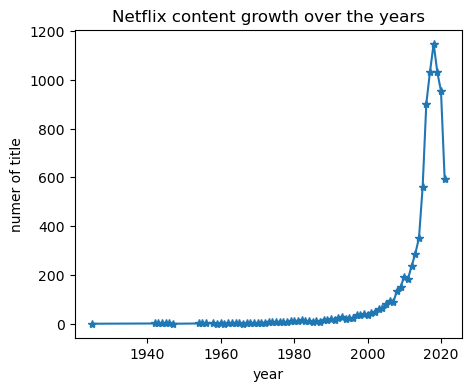

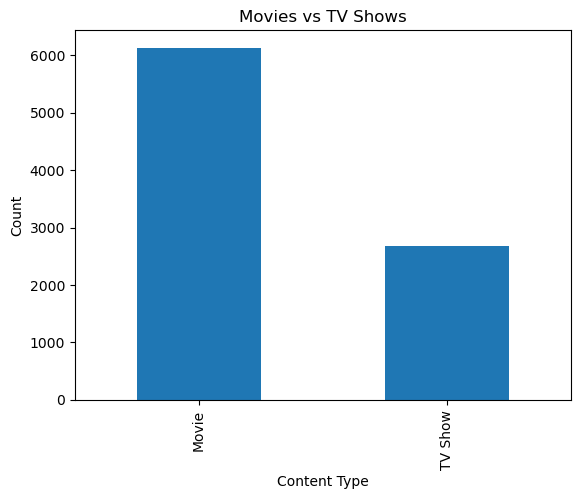

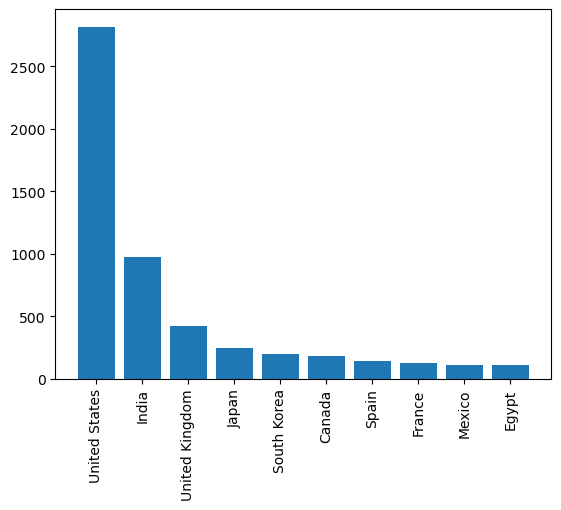

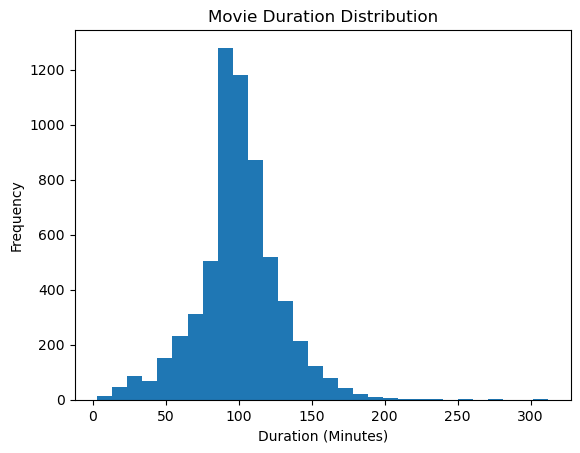

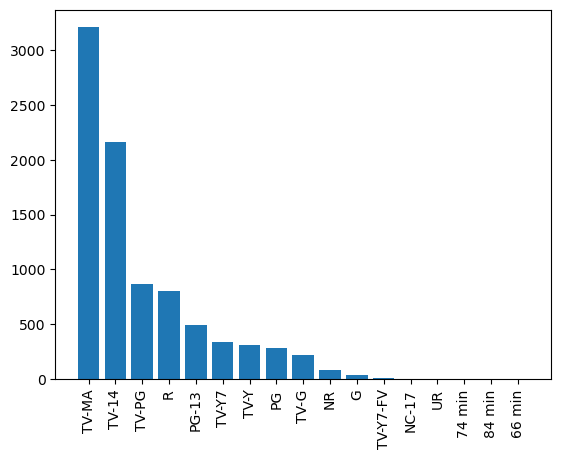

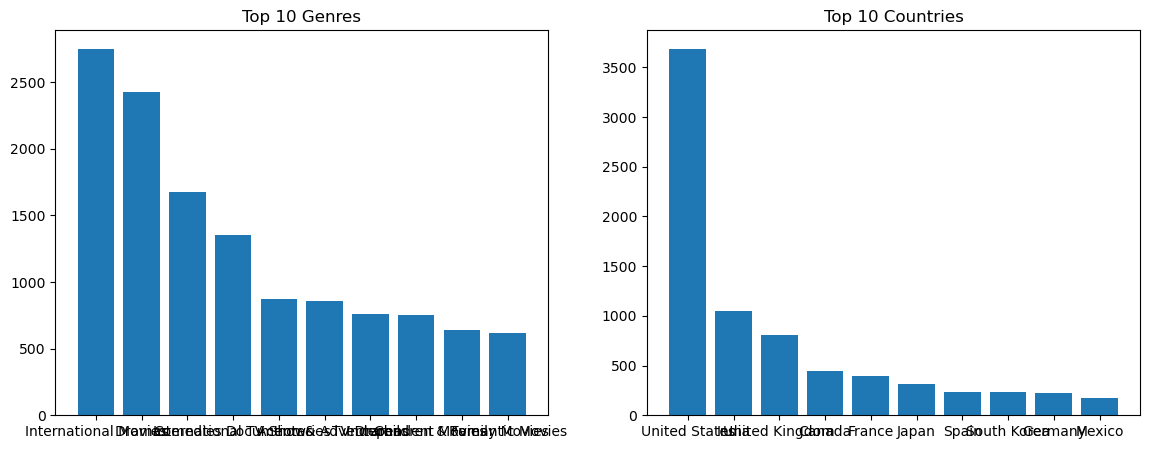

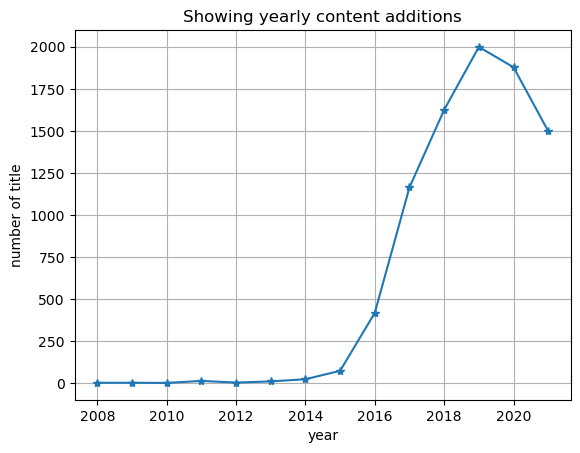

In [57]:
nt.Matplotlib(data)

# Seaborn

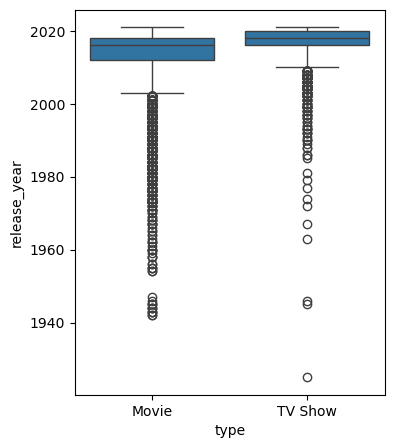

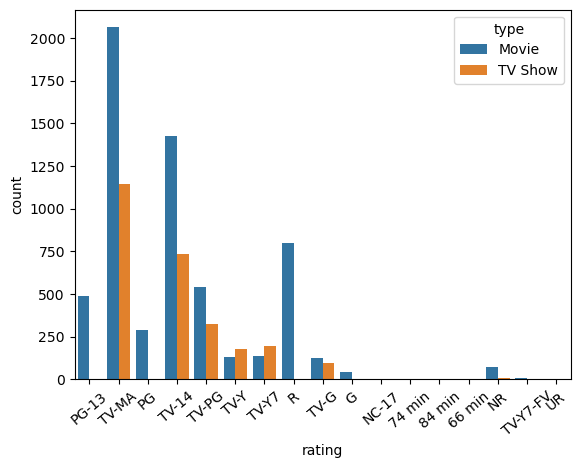

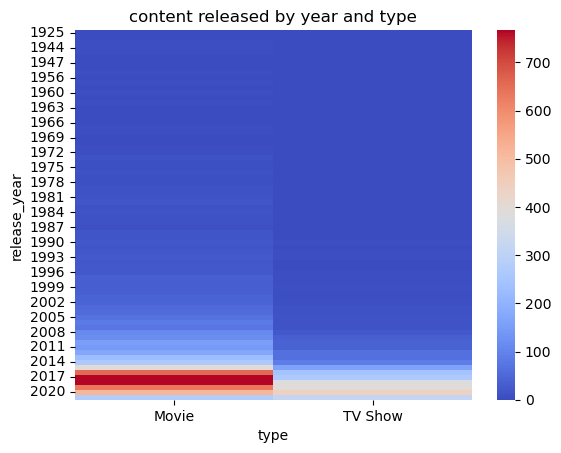

C:\Users\rahul\AppData\Local\Temp\ipykernel_9136\3407473381.py:166: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movie['duration'] = movie['duration'].str.replace('min',' ').astype(float)


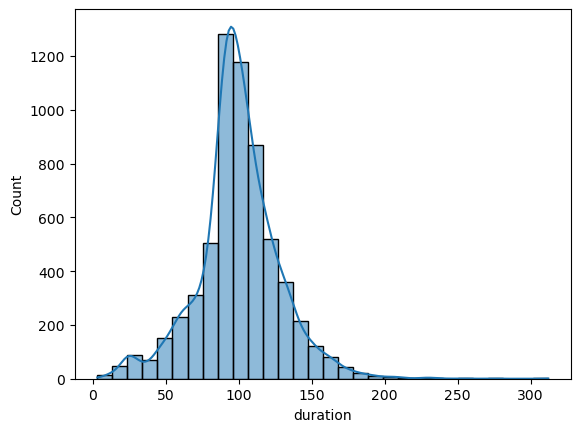

C:\Users\rahul\AppData\Local\Temp\ipykernel_9136\3407473381.py:171: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movie['duration'] = movie['duration'].str.replace('min',' ',regex=False).astype(float)


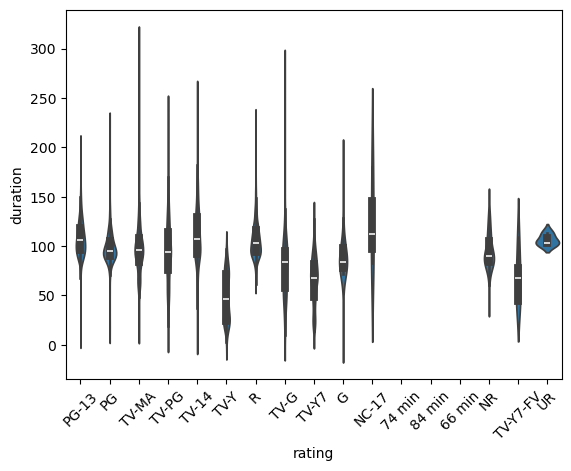

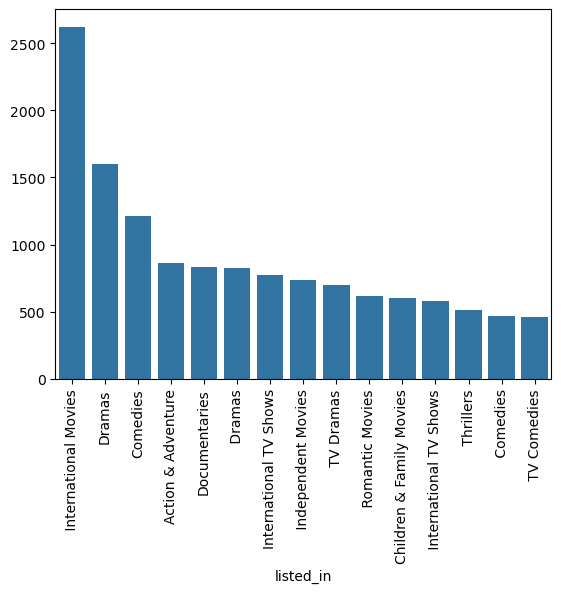

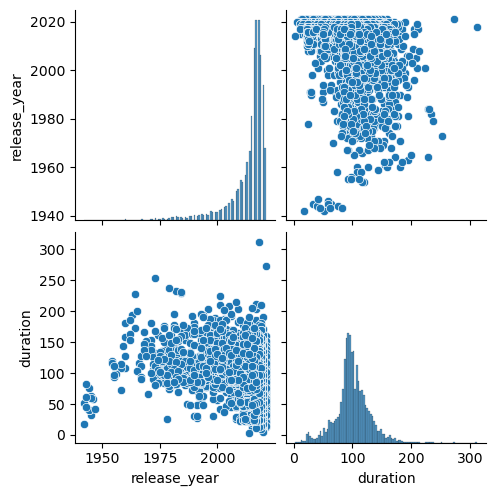

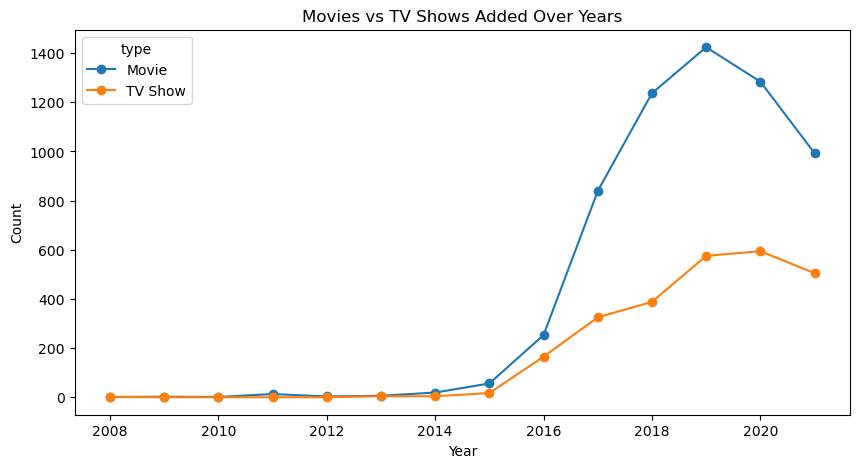

In [58]:

nt.seaborn(data)